In [1]:
# Zachary Katz
# zachary_katz@mines.edu


"""
Plot Figures 4, S4 for Whillans Catalog Paper
Figure 4: Slip distance and time since prior event histogram for LA02
Figure S4: Slip distance and time since prior event histogram for all stations

v1.0: 01 November 2024
    Plots for Whillans Catalog Paper
v2.0: 08 March 2025
    Paper Version
v2.1: 27 June 2025
    Paper R1
"""

# Imports
import datetime
import sys
import os

import matplotlib.pyplot as plt


import pandas as pd
import numpy as np


%reload_ext autoreload
%autoreload


################################################################################
########################## User Defined Variables ##############################

min_stas = 2  # Which catalog to use
tide_dir = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background"
tide_mod = "CATS2008-v2023"
events_path = "../Events_2stas"

# Path to Tides
# Likely should be "{pwd}/src/Tides"
path = (
    "/mnt/c/users/ZacharyKatz/Desktop/Papers/WhillansCatPaper/WhillansCatalogPaper/src/"
)

# Path to background data files
# {path_to_dir}/scripps_antarctica_polygons_v1.shp
gl_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/Antarctica_masks/scripps_antarctica_polygons_v1.shp"
vel_mag_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/antarctic_ice_vel_phase_map_v01-vmag.nc"
moa_path = (
    "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/moa750_2009_hp1_v1.1.tif"
)
########################## User Defined Variables ##############################
################################################################################

sys.path.insert(
    0,
    path,
)

In [2]:
# Load slip times based on second derivative
ev_data = {"event": [], "trace_time": []}
df = pd.read_csv(f"../AllEventStartTimes{min_stas}stas.txt", sep="\t")
ev_data["ev_time"] = df["EventStartTime"]

folders = [f"{events_path}/{i}_{i}Events2stas" for i in range(2008, 2020)]
for folder in folders:
    print(f"Loading {folder}")
    for file in os.listdir(folder):
        df = pd.read_csv(f"{folder}/{file}", sep="\t")
        ev_data["event"].append(df)

# Load no data from txt file
no_data = {"interval": [], "starts": [], "ends": []}
df = pd.read_csv(f"../no_data_{min_stas}stas.txt", sep="\t")
no_data["starts"] = df["start"]
no_data["ends"] = df["end"]
diff = [
    datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S")
    - datetime.datetime.strptime(y, "%Y-%m-%d %H:%M:%S")
    for x, y in zip(no_data["ends"], no_data["starts"])
]
no_data["interval"] = diff
print(len(ev_data["ev_time"]), "events loaded")

Loading ../Events_2stas/2008_2008Events2stas
Loading ../Events_2stas/2009_2009Events2stas
Loading ../Events_2stas/2010_2010Events2stas
Loading ../Events_2stas/2011_2011Events2stas
Loading ../Events_2stas/2012_2012Events2stas
Loading ../Events_2stas/2013_2013Events2stas
Loading ../Events_2stas/2014_2014Events2stas
Loading ../Events_2stas/2015_2015Events2stas
Loading ../Events_2stas/2016_2016Events2stas
Loading ../Events_2stas/2017_2017Events2stas
Loading ../Events_2stas/2018_2018Events2stas
Loading ../Events_2stas/2019_2019Events2stas
5150 events loaded


In [3]:
# Calculate time since last events
time_since_last_ev = [
    datetime.timedelta(seconds=1000000)
]  # Set large for first event because prior event time unknown
for i, event in enumerate(ev_data["ev_time"]):
    if i > 0:
        current = datetime.datetime.strptime(event, "%Y-%m-%d %H:%M:%S")
        prior = datetime.datetime.strptime(
            ev_data["ev_time"][i - 1], "%Y-%m-%d %H:%M:%S"
        )
        diff = current - prior
        # Check if data gap in current - prior and remove event from consideration
        for j, gap in enumerate(no_data["interval"]):
            if (
                prior
                < datetime.datetime.strptime(no_data["ends"][j], "%Y-%m-%d %H:%M:%S")
                < current
            ):
                diff = datetime.timedelta(seconds=1000000)
        time_since_last_ev.append(diff)
ev_data["time_since_last_ev"] = time_since_last_ev
print([(a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]])
tsle = [
    i
    for i, x in enumerate(ev_data["time_since_last_ev"])
    if x == datetime.timedelta(seconds=1000000)
]
print(len(tsle))

[277.77777777777777, 17.354166666666668, 21.766666666666666, 10.758333333333333, 13.254166666666666, 19.1125, 22.970833333333335, 10.4875, 11.895833333333334, 9.975, 14.345833333333333, 9.975, 14.845833333333333, 9.9875, 14.658333333333333, 12.0625, 13.1375, 9.808333333333334, 15.225, 10.9875, 14.591666666666667, 10.625, 15.1, 23.866666666666667, 8.416666666666666, 16.3375, 21.929166666666667, 10.666666666666666, 14.5875, 18.954166666666666, 14.941666666666666, 10.7375, 20.645833333333332, 13.025, 12.041666666666666, 11.0125, 13.125, 9.525, 15.145833333333334, 8.875, 15.625, 8.2875, 16.266666666666666, 8.525, 16.9125, 8.5125, 16.4875, 8.55, 19.804166666666667, 16.733333333333334, 11.6625, 12.2, 12.983333333333333, 13.9, 21.4, 20.2, 12.008333333333333, 11.979166666666666, 11.516666666666667, 12.891666666666667, 11.183333333333334, 13.1125, 11.1, 13.5125, 11.545833333333333, 13.420833333333333, 10.85, 14.083333333333334, 10.420833333333333, 14.325, 11.045833333333333, 16.941666666666666,

In [4]:
tsle_hr = [
    (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
]
sorted_tsle_hr = np.sort(tsle_hr)
print(sorted_tsle_hr)

[  2.2          6.00833333   6.4625     ... 277.77777778 277.77777778
 277.77777778]


Dists: 5150
Time since last event: 5150
4119


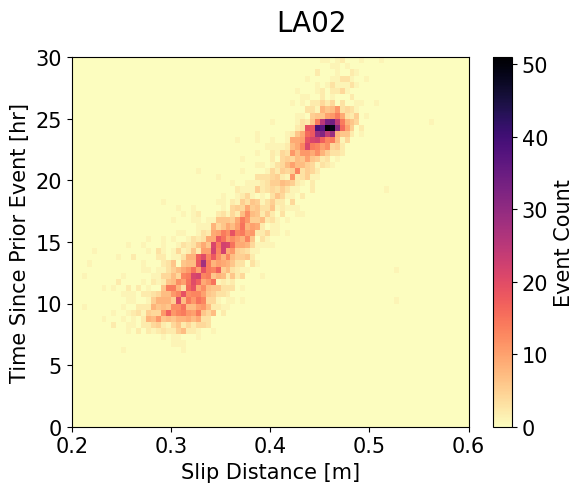

In [8]:
############
# Figure 4 #
############

# Slip dist of station La02
station = "la02"
sta_title = "LA02"
dists = np.empty(len(ev_data["event"]))
dists[:] = np.nan

for i, evt in enumerate(ev_data["event"]):
    try:
        col_of_interest = evt[f"{station}x"]
        dists[i] = col_of_interest.iloc[-1] - col_of_interest.iloc[0]
    except Exception:
        pass

# Make 2d histogram
hr_since_last_ev = [
    (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
]

print(f"Dists: {len(dists)}")
print(f"Time since last event: {len(hr_since_last_ev)}")
fig, ax = plt.subplots()
cax = ax.hist2d(
    dists,
    hr_since_last_ev,
    bins=(np.arange(0.2, 0.601, 0.005), np.arange(0, 30.01, 0.5)),
    cmap="magma_r",
)

cbar = plt.colorbar(cax[3])
cbar.ax.tick_params(labelsize=15)
cbar.ax.set_ylabel("Event Count", size=15)
ax.set_ylabel("Time Since Prior Event [hr]", size=15)
ax.set_xlabel("Slip Distance [m]", size=15)
ax.tick_params(labelsize=15)
fig.suptitle(f"{sta_title}", size=20)

fig.savefig("Figure4.png", dpi=300, bbox_inches="tight")
print(len(dists) - np.sum(np.isnan(dists)))

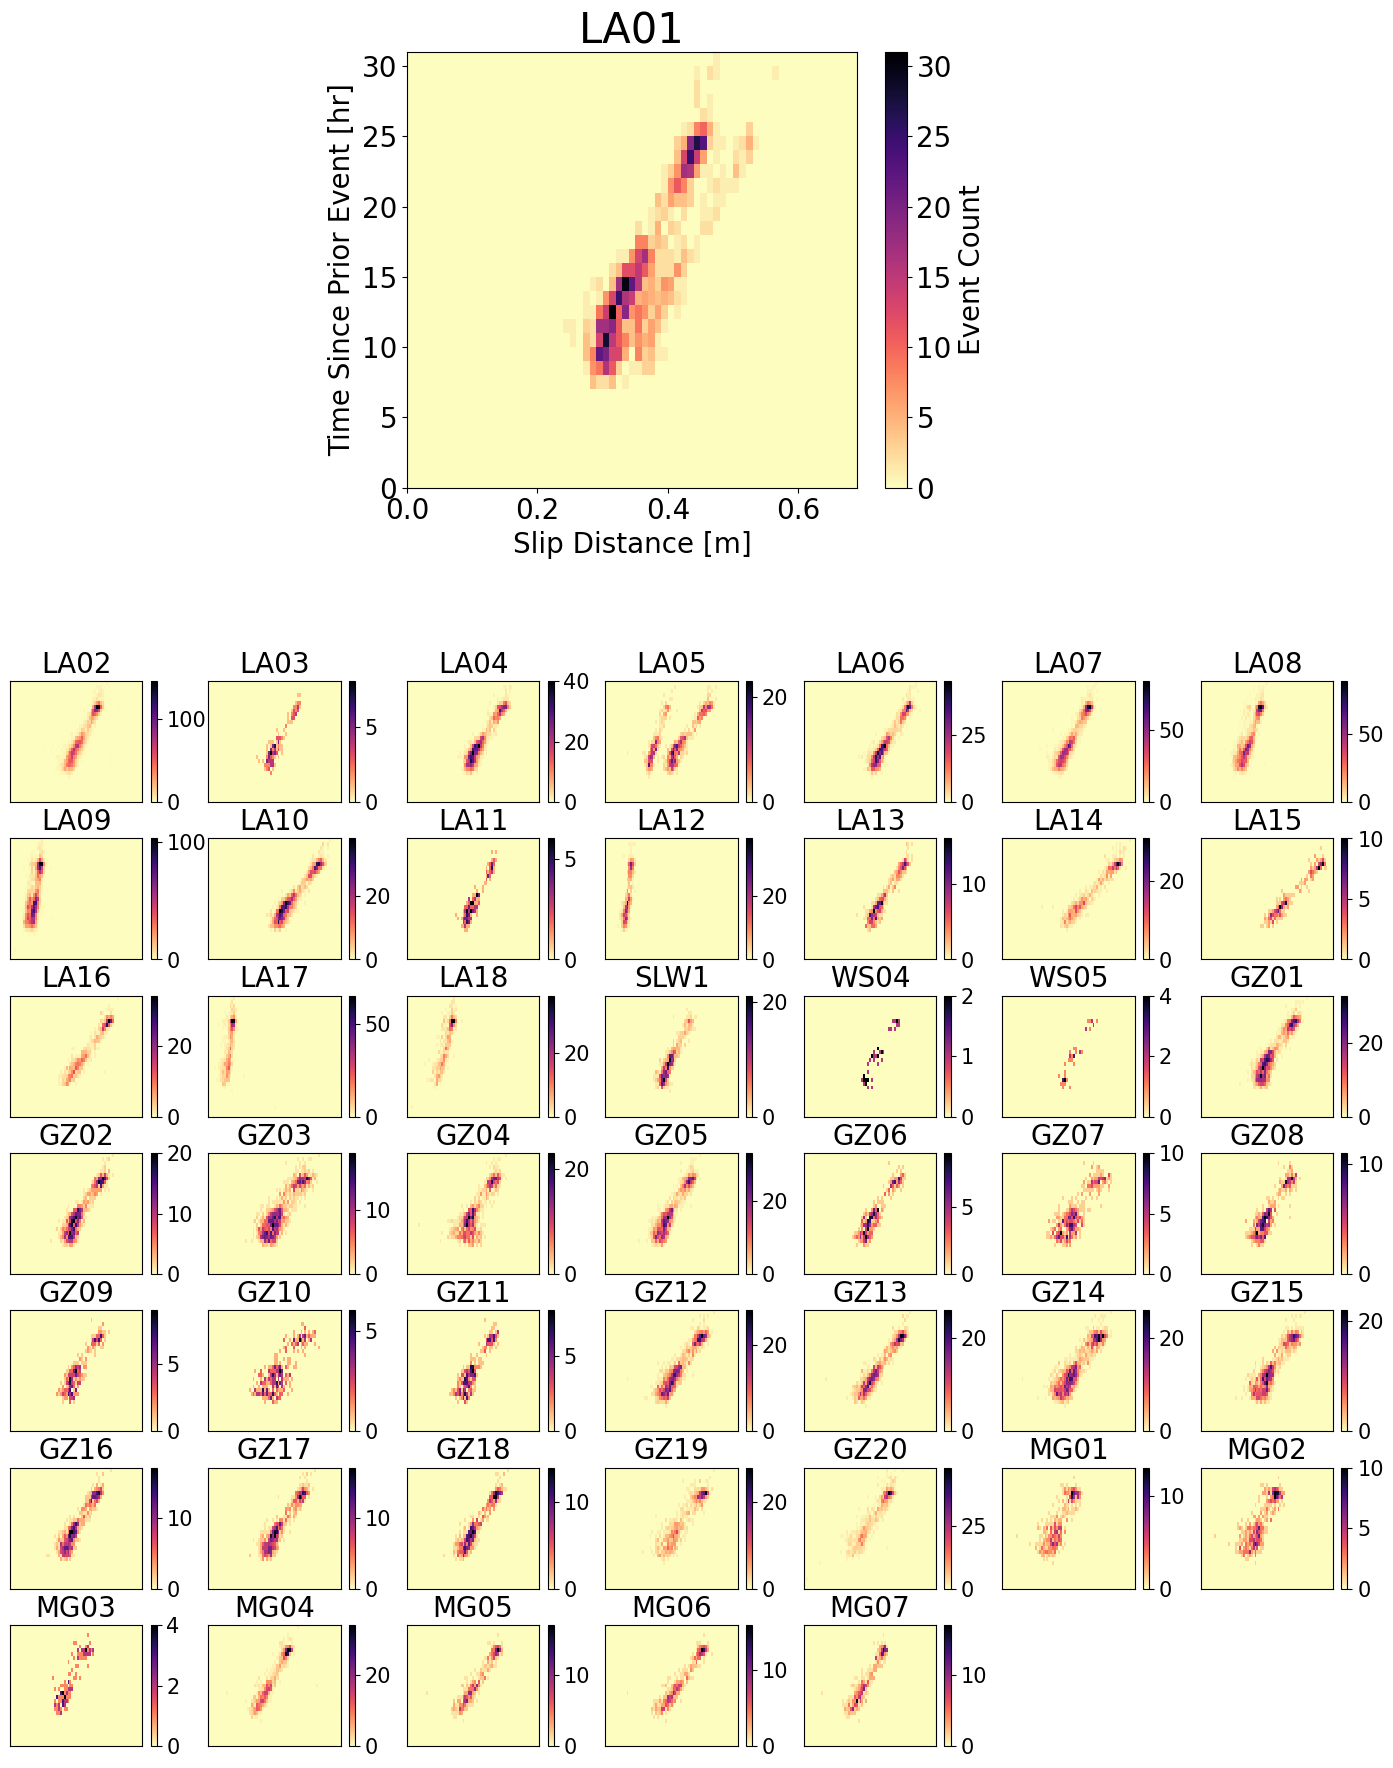

In [10]:
#############
# Figure S4 #
#############
import matplotlib.gridspec as gridspec

stations = [
    "la01",
    "la02",
    "la03",
    "la04",
    "la05",
    "la06",
    "la07",
    "la08",
    "la09",
    "la10",
    "la11",
    "la12",
    "la13",
    "la14",
    "la15",
    "la16",
    "la17",
    "la18",
    "slw1",
    "ws04",
    "ws05",
    "gz01",
    "gz02",
    "gz03",
    "gz04",
    "gz05",
    "gz06",
    "gz07",
    "gz08",
    "gz09",
    "gz10",
    "gz11",
    "gz12",
    "gz13",
    "gz14",
    "gz15",
    "gz16",
    "gz17",
    "gz18",
    "gz19",
    "gz20",
    "mg01",
    "mg02",
    "mg03",
    "mg04",
    "mg05",
    "mg06",
    "mg07",
]

n_stations = len(stations)
ncols = 7
nrows_small = int(np.ceil((n_stations - 1) / ncols))  # skip la01
nrows_total = nrows_small + 4

fig = plt.figure(figsize=(ncols * 2.5, nrows_total * 2))
gs = gridspec.GridSpec(nrows_total, ncols, figure=fig)
big_row_start = 0
big_row_end = 3
big_col_start = 2
big_col_end = 5

ax0 = fig.add_subplot(gs[big_row_start:big_row_end, big_col_start:big_col_end])
station = stations[0]
dists = np.empty(len(ev_data["event"]))
dists[:] = np.nan

for i, evt in enumerate(ev_data["event"]):
    try:
        col_of_interest = evt[f"{station}x"]
        dists[i] = col_of_interest.iloc[-1] - col_of_interest.iloc[0]
    except Exception:
        pass

# Make 2d histogram
hr_since_last_ev = [
    (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
]
counts, xedges, yedges, image = ax0.hist2d(
    dists,
    hr_since_last_ev,
    bins=(np.arange(0, 0.7, 0.01), np.arange(0, 32, 1)),
    cmap="magma_r",
)

cbar = plt.colorbar(image)
cbar.ax.tick_params(labelsize=20)
cbar.ax.set_ylabel("Event Count", size=20)
ax0.set_ylabel("Time Since Prior Event [hr]", size=20)
ax0.set_xlabel("Slip Distance [m]", size=20)
ax0.tick_params(labelsize=20)
ax0.set_title(f"{station.upper()}", size=30)

for q, station in enumerate(
    stations[1:], start=0
):  # skip la01, start at 0 for subplot grid
    row = (q // ncols) + 4  # offset by +1 row
    col = q % ncols
    ax = fig.add_subplot(gs[row, col])

    dists = np.empty(len(ev_data["event"]))
    dists[:] = np.nan

    for i, evt in enumerate(ev_data["event"]):
        try:
            col_of_interest = evt[f"{station}x"]
            dists[i] = col_of_interest.iloc[-1] - col_of_interest.iloc[0]
        except Exception:
            pass

    # Make 2d histogram
    hr_since_last_ev = [
        (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
    ]
    counts, xedges, yedges, image = ax.hist2d(
        dists,
        hr_since_last_ev,
        bins=(np.arange(0, 0.7, 0.01), np.arange(0, 32, 1)),
        cmap="magma_r",
    )

    cbar = plt.colorbar(image)
    cbar.ax.tick_params(labelsize=15)
    # cbar.ax.set_ylabel('Event Percentage',size=15)
    # ax.set_ylabel('Time since prior event [hr]',size=15)
    # ax.set_xlabel('Slip Distance [m]',size=15)
    ax.tick_params(labelsize=15)
    ax.set_title(f"{station.upper()}", size=20)

    # Remove x and y axes labels for all but the first col and last row
    ax.set_xticks([])
    ax.set_yticks([])
# fig.tight_layout()
plt.subplots_adjust(hspace=0.3)
fig.savefig("FigureS4.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_42001/2352404312.py:30: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


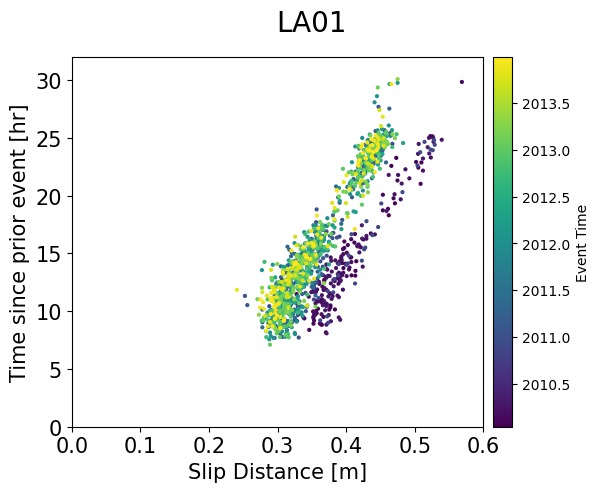

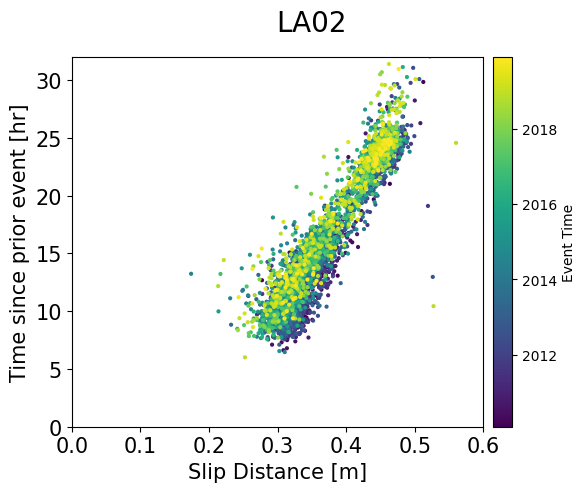

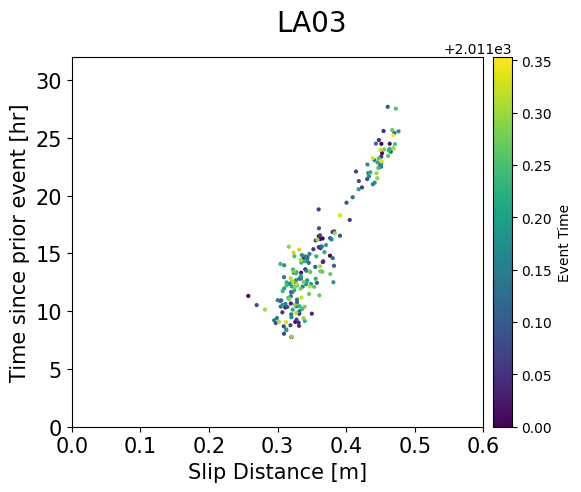

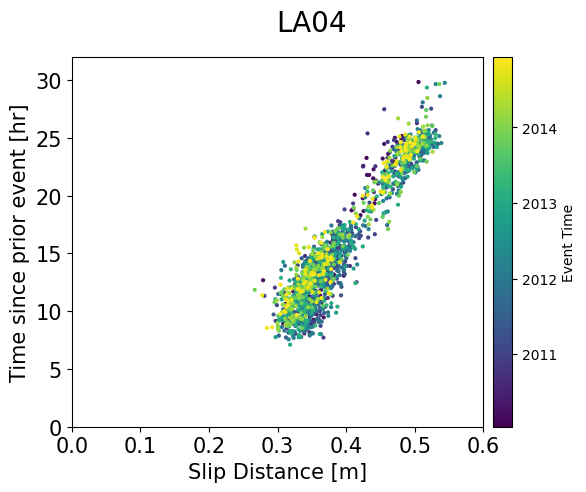

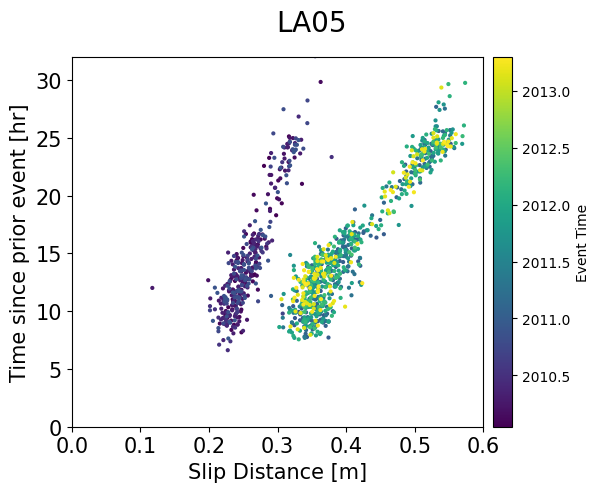

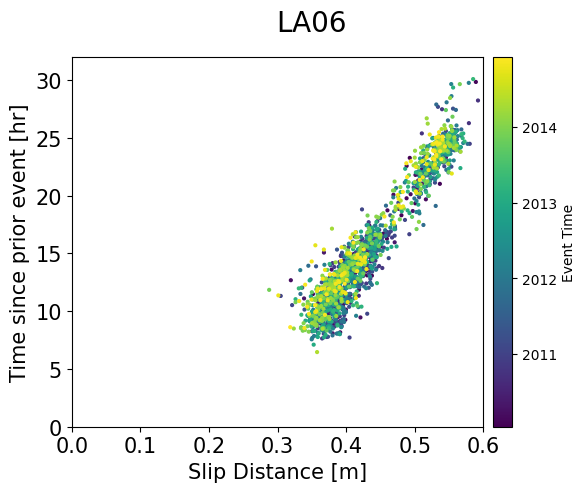

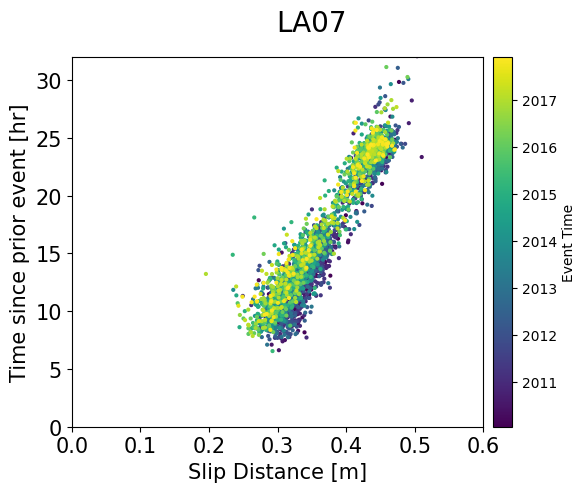

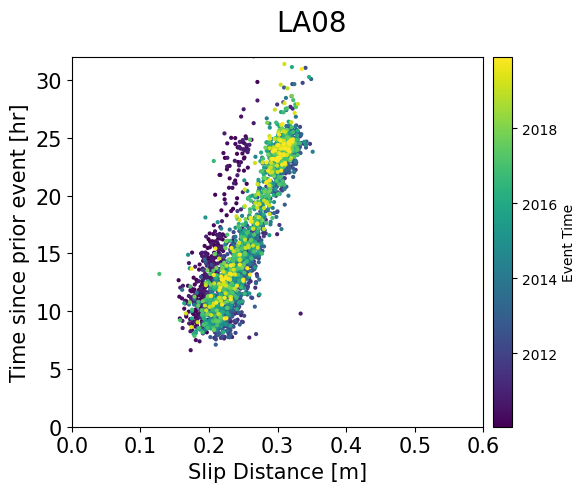

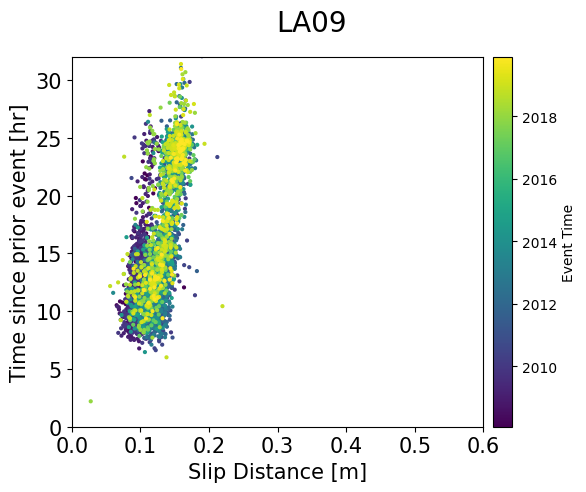

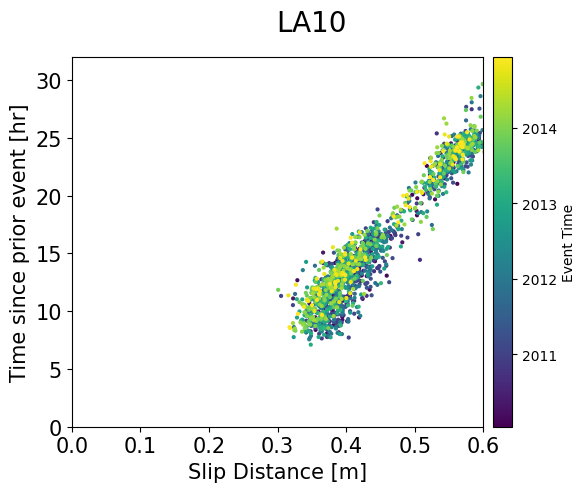

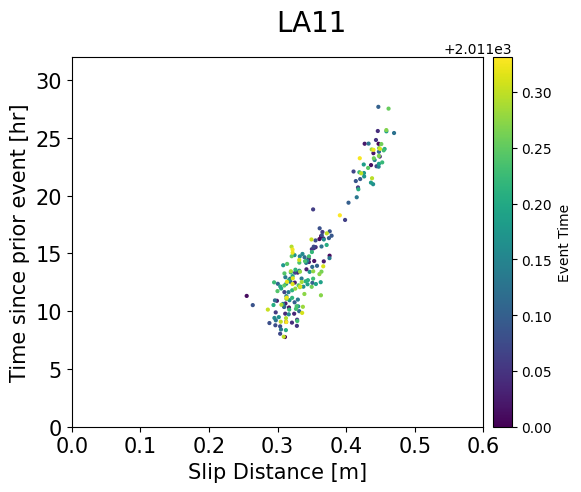

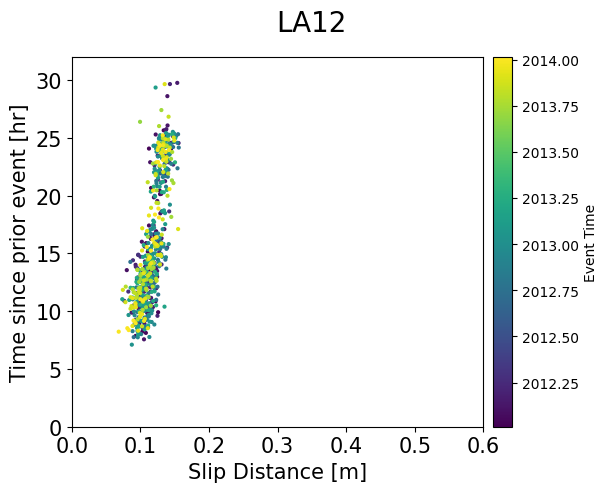

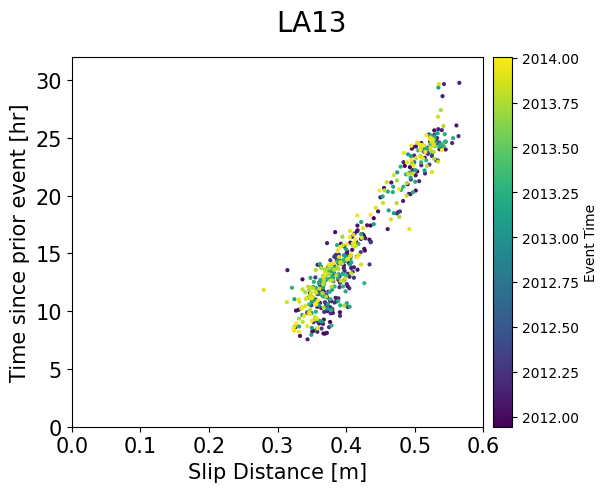

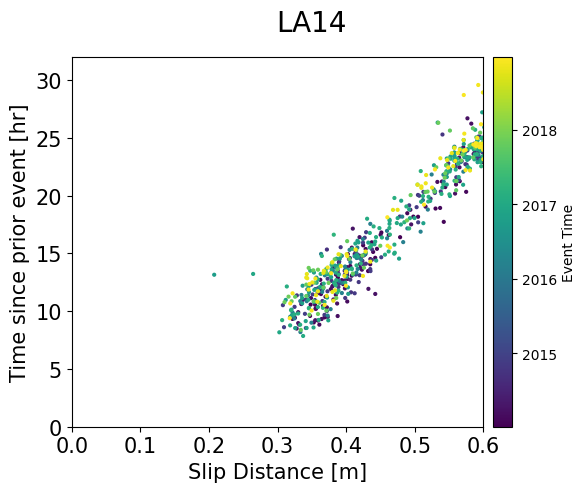

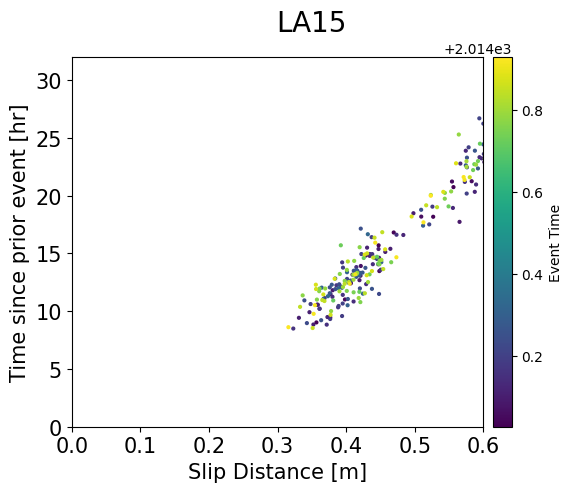

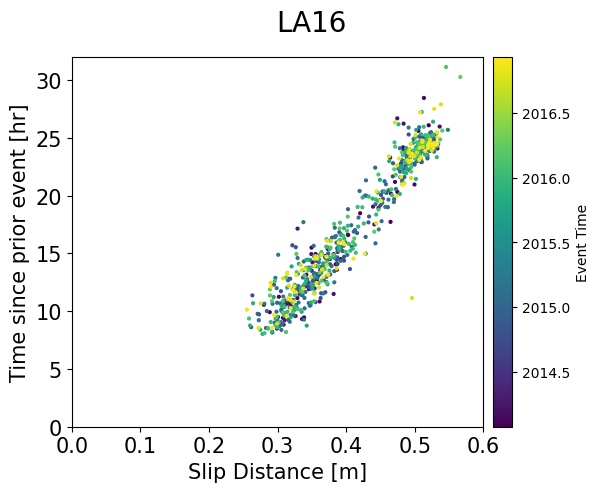

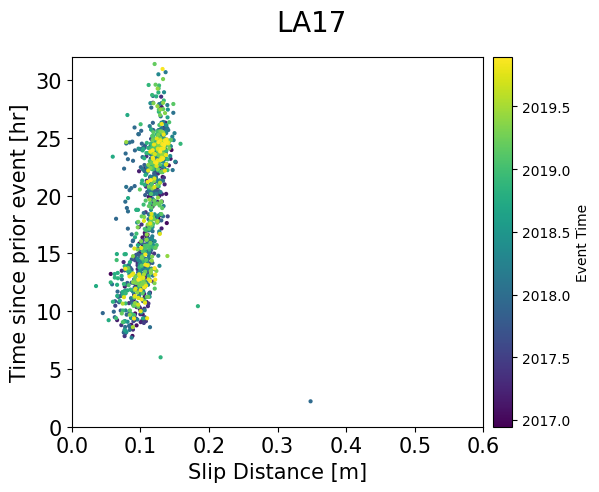

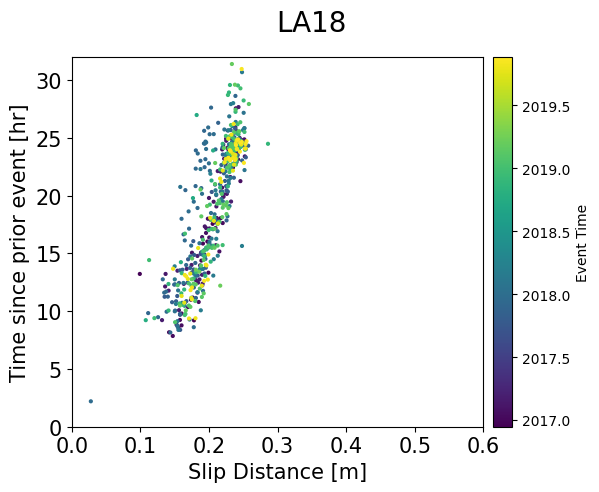

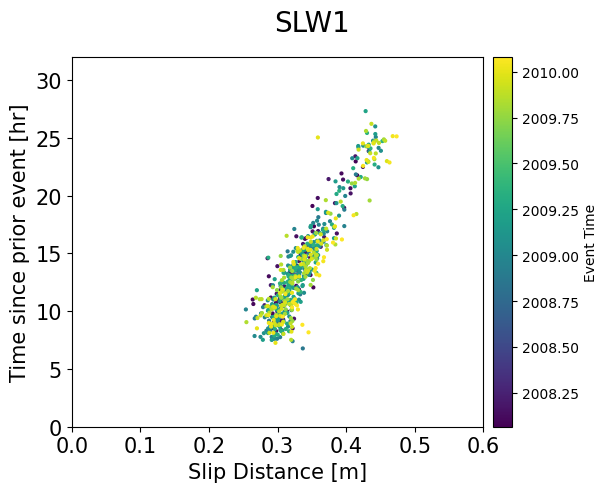

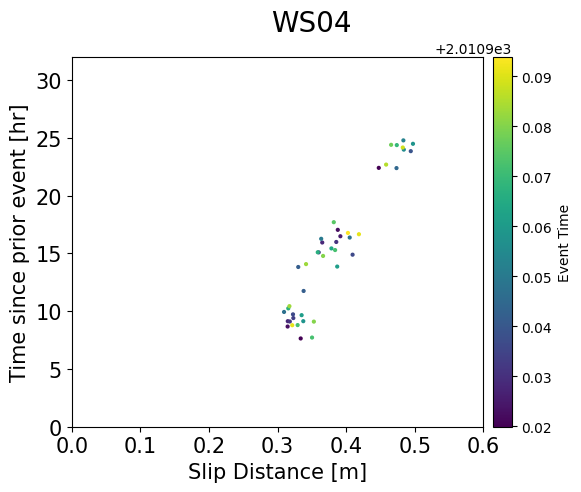

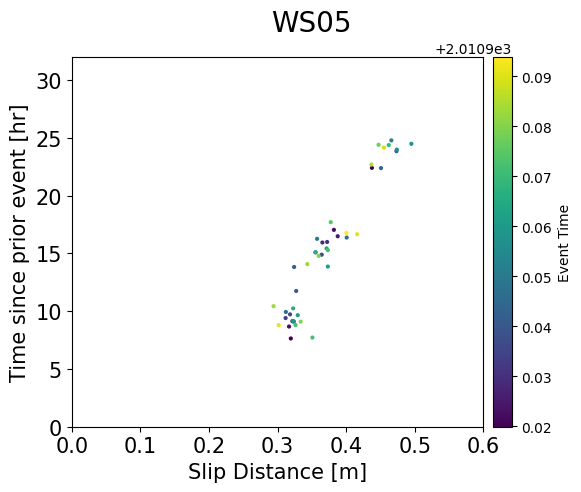

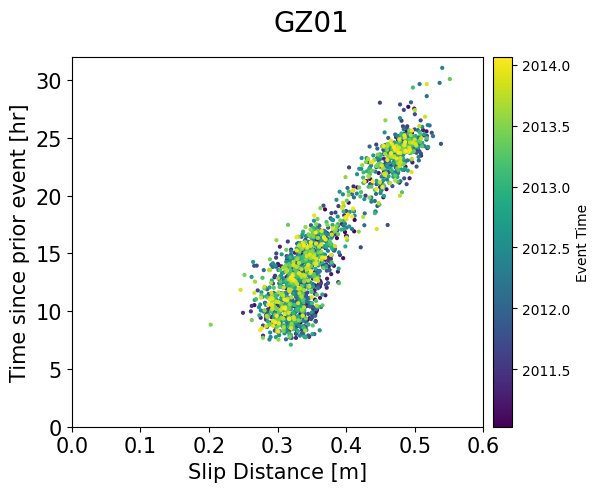

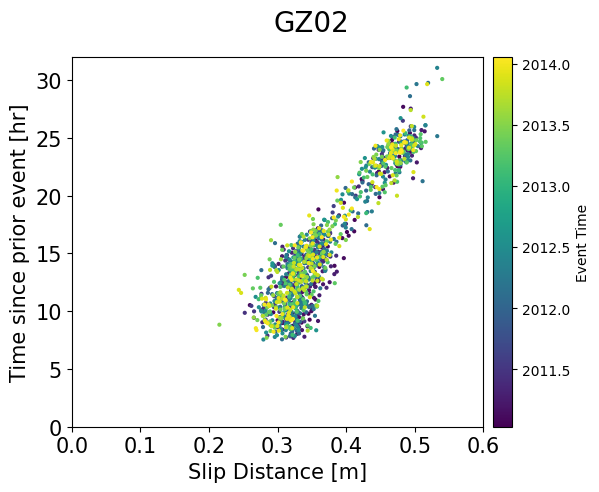

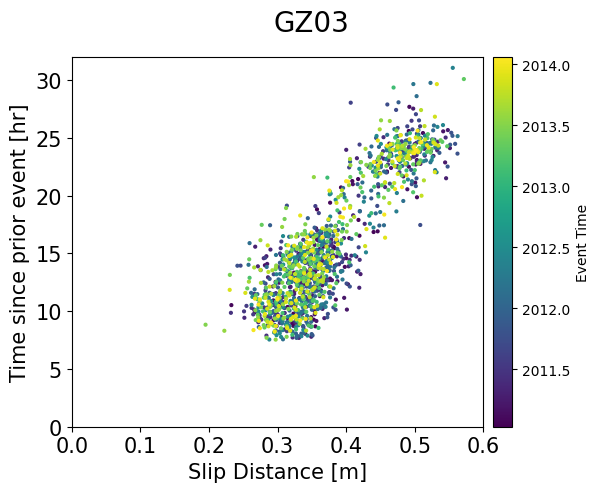

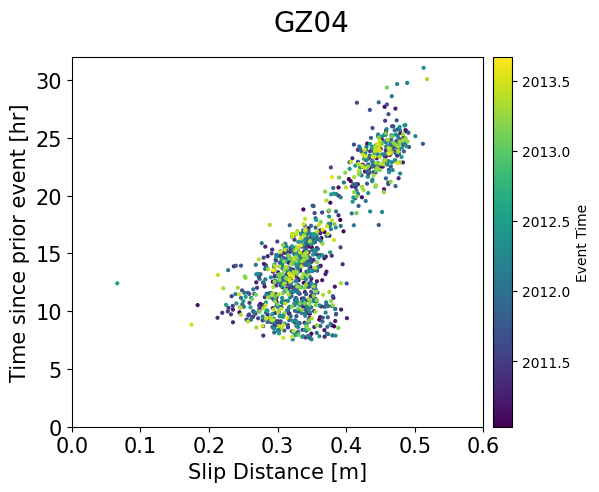

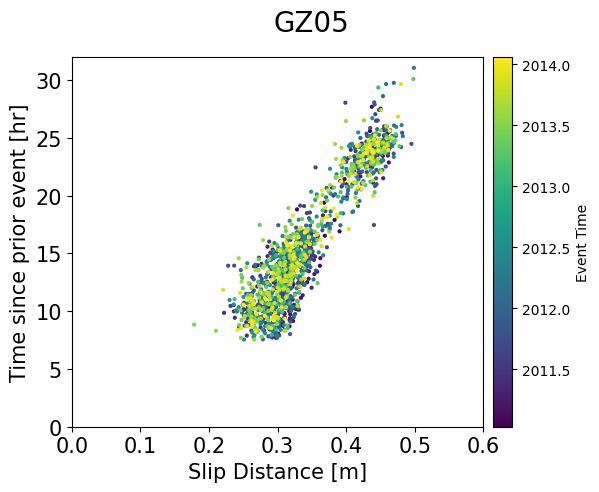

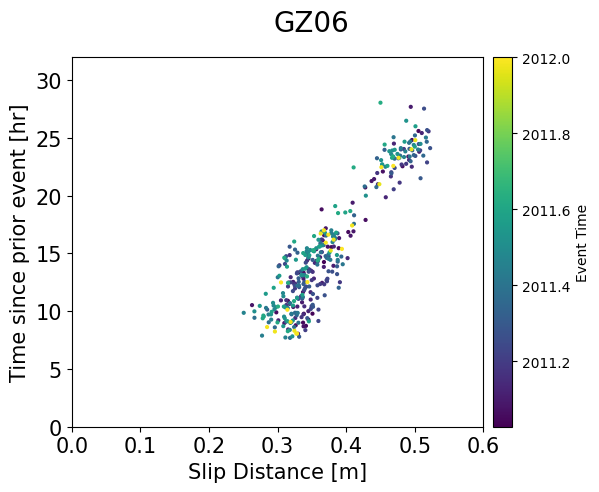

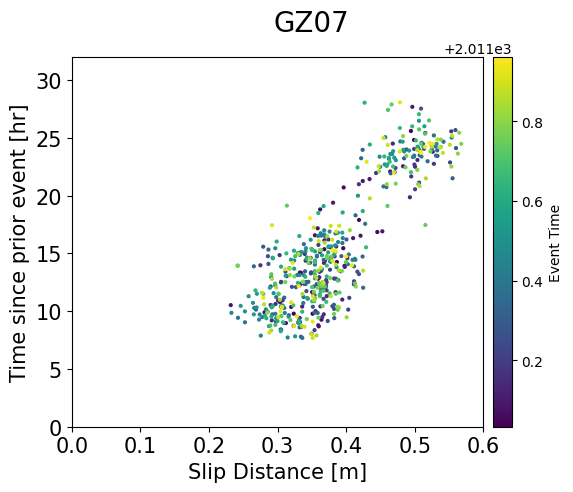

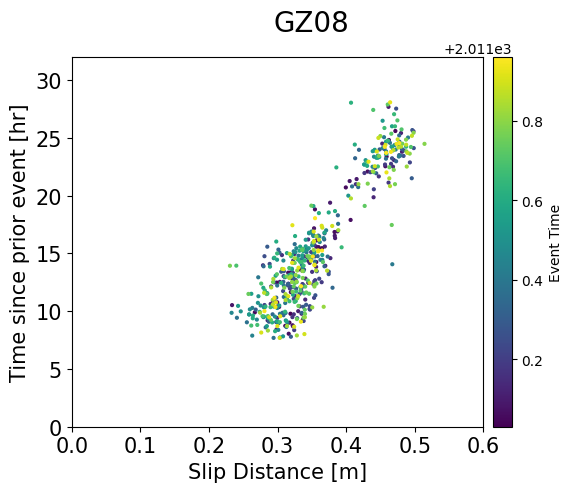

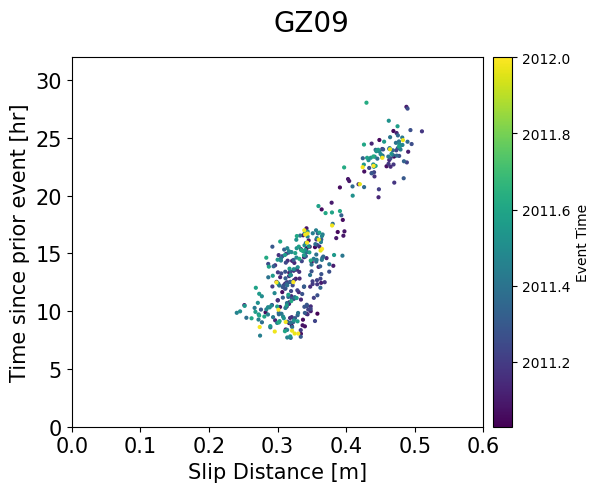

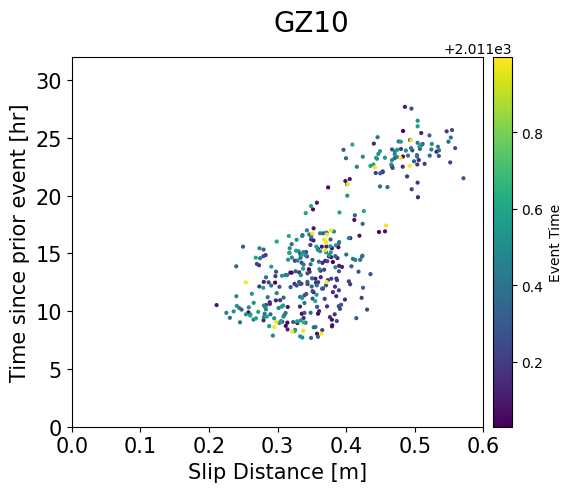

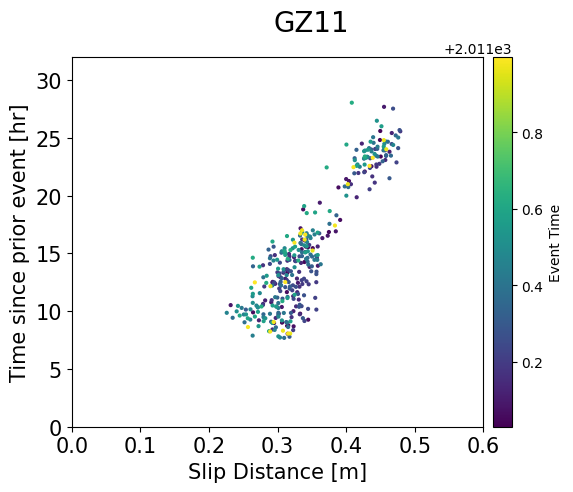

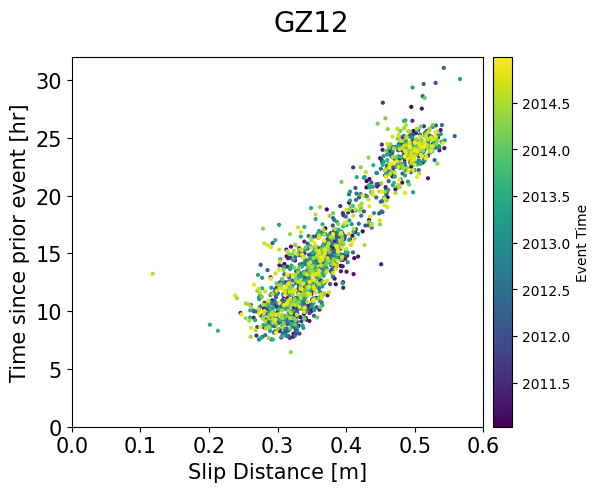

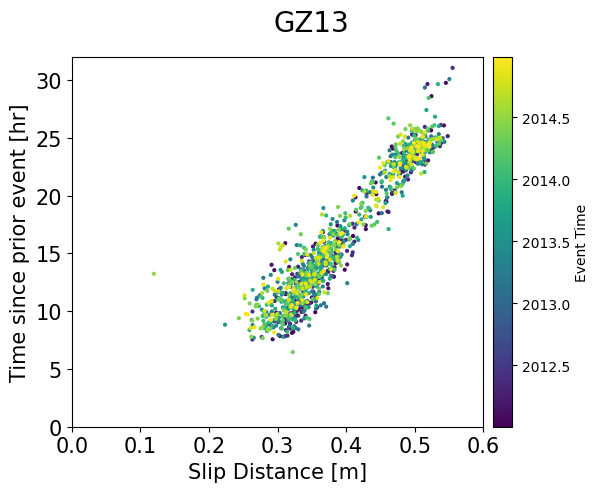

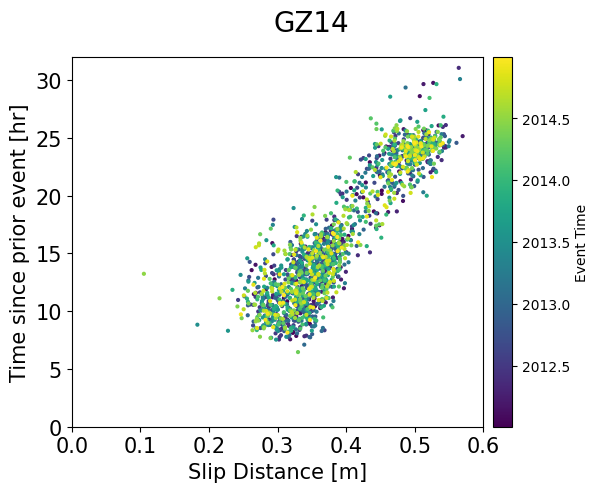

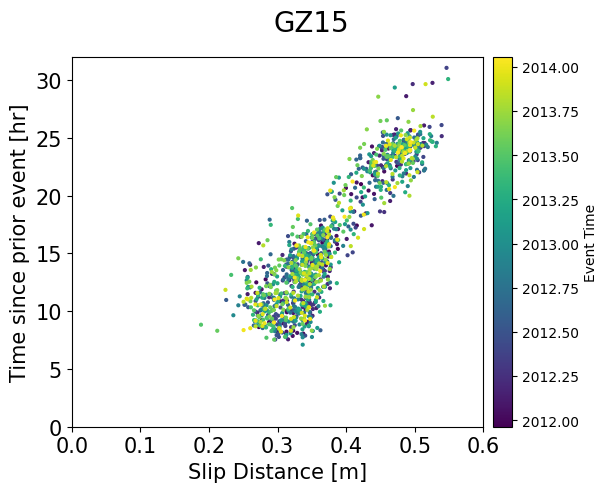

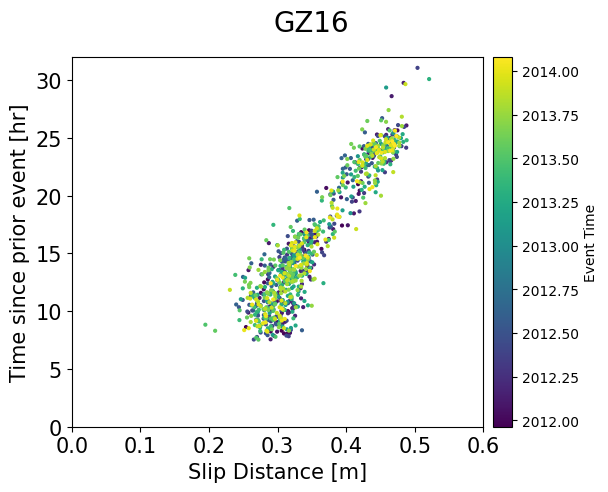

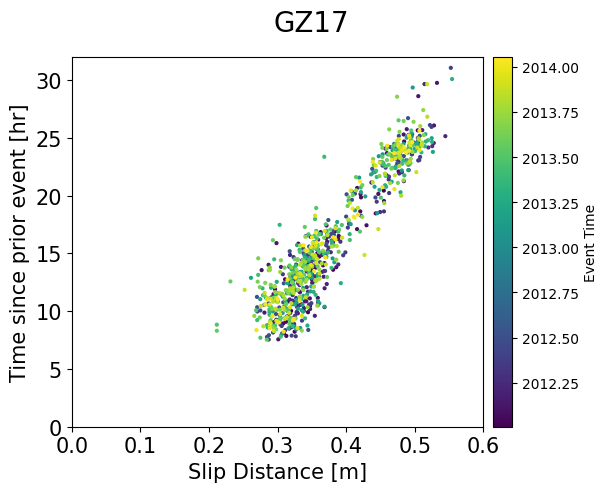

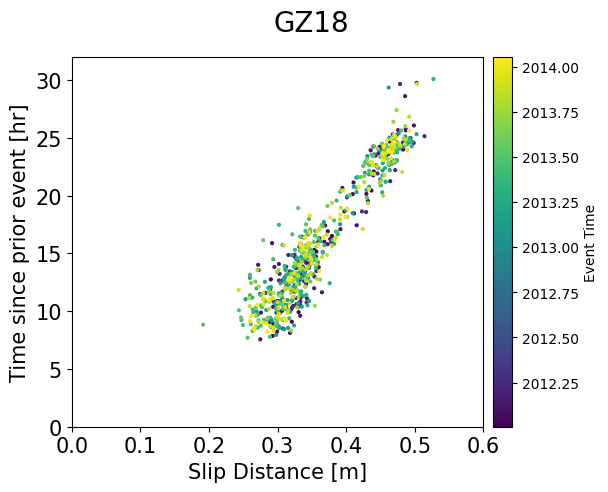

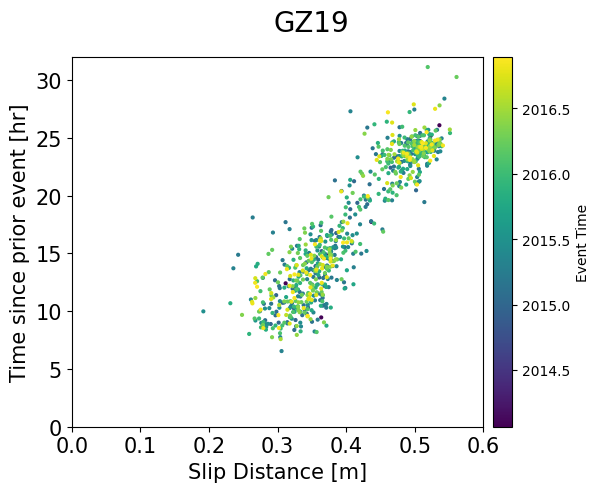

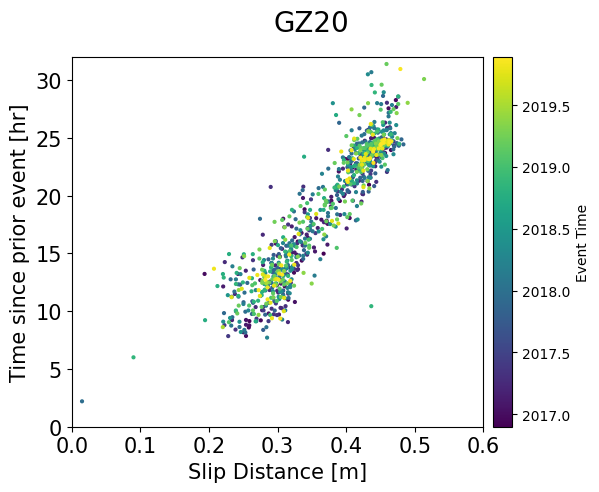

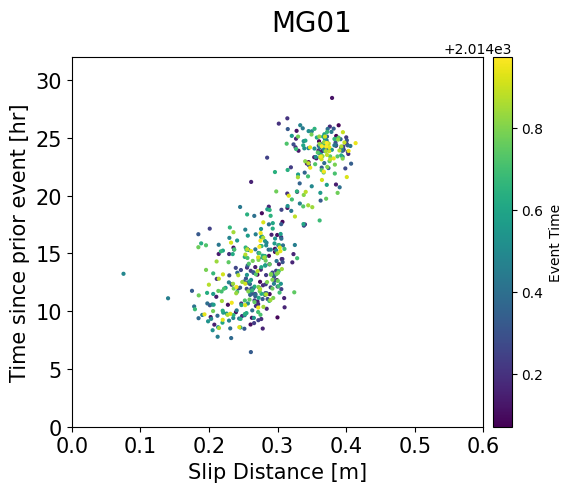

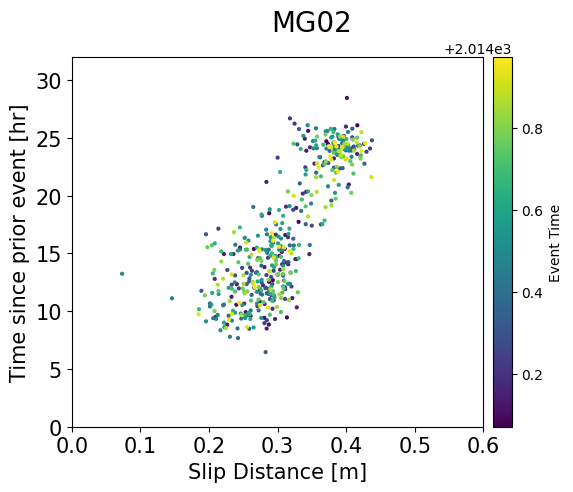

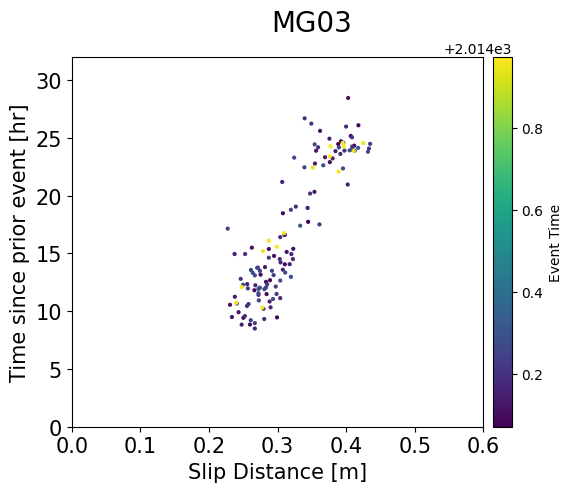

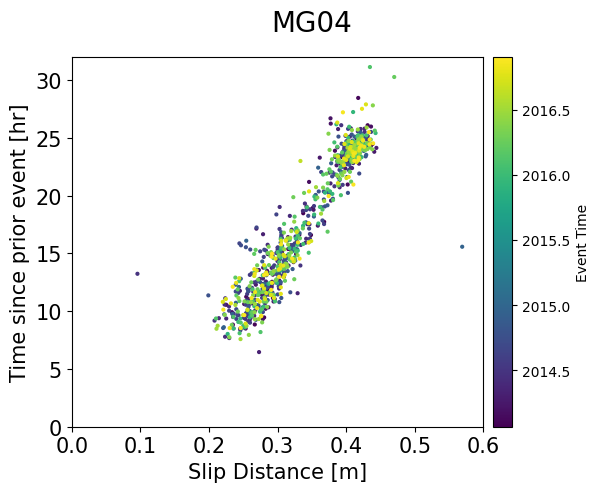

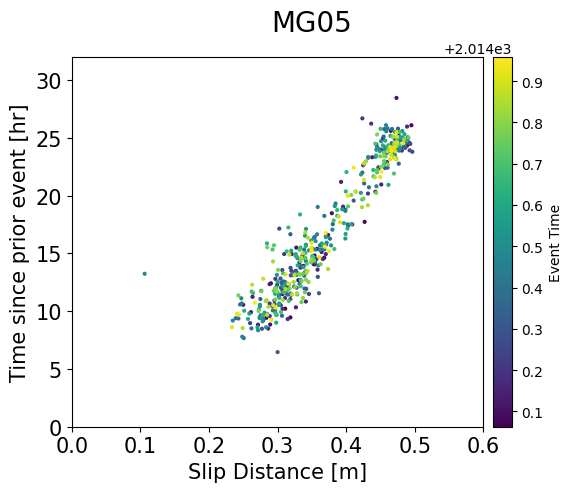

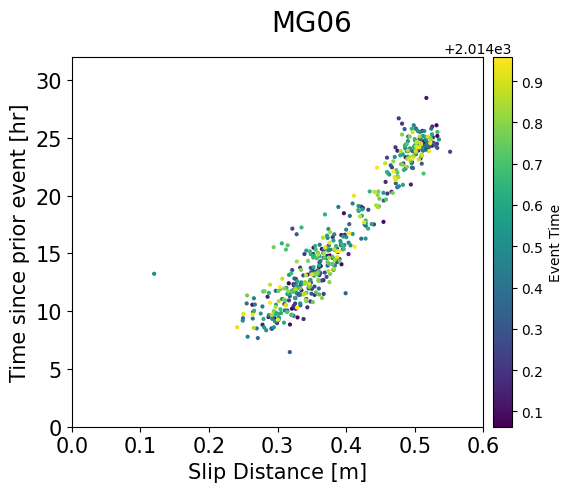

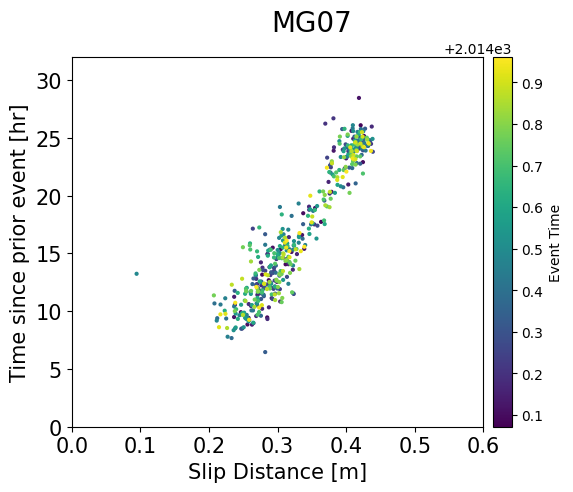

In [14]:
for station in stations[:]:
    dists = np.empty(len(ev_data["event"]))
    dists[:] = np.nan

    for i, evt in enumerate(ev_data["event"]):
        try:
            col_of_interest = evt[f"{station}x"]
            dists[i] = col_of_interest.iloc[-1] - col_of_interest.iloc[0]
        except Exception:
            pass

    # Make 2d scatterplot
    hr_since_last_ev = [
        (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
    ]

    # color by time as decimal year
    clr = np.array(
        [
            datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S").year
            + (
                datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday
                - 1
            )
            / 365.25
            for x in ev_data["ev_time"]
        ]
    )

    fig, ax = plt.subplots()
    cbar = ax.scatter(dists, hr_since_last_ev, s=4, c=clr)
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 32)
    ax.set_xlabel("Slip Distance [m]", size=15)
    ax.set_ylabel("Time since prior event [hr]", size=15)
    ax.tick_params(labelsize=15)
    fig.suptitle(f"{station.upper()}", size=20)
    fig.colorbar(cbar, label="Event Time", orientation="vertical", pad=0.02)